## Notebook 1: Exploratory Data Analysis & Feature Pipeline Construction

AuraCart Sentinel — Production-Grade E-Commerce Analytics and MLOps System  
Module: ITS 2140 — Machine Learning: Foundations to Production Systems

**Purpose:** 
- Comprehensive exploration of *millat/e-commerce-orders* dataset
- Identify data quality and class balance issues
- Engineer domain-aware features
- Build reusable preprocessing pipeline (Scikit-learn ColumnTransformer)

### 1. Load All Dependencies

Centralized import block ensures complete visibility of external libraries:

| Library | Purpose |
|---------|---------|
| pandas / numpy | Data manipulation, numerical computing |
| matplotlib / seaborn | Visualization (distributions, correlations) |
| scikit-learn | ML preprocessing, pipeline, serialization |
| joblib / os | Model persistence, filesystem operations |

In [1]:
# ── Core data libraries ──────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")

# ── Scikit-learn preprocessing & pipeline ────────────────────────────
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# ── Serialization & utilities ────────────────────────────────────────
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

### 2. Ingest Data from Hugging Face

**Data Source:** `millat/e-commerce-orders` (Hugging Face Datasets)

Process:
1. Fetch via `datasets` library
2. Extract *train* split → pandas DataFrame
3. Single auditable source across all notebooks

In [ ]:
# Install the HuggingFace datasets library (if not already available)
%pip install -q datasets

from datasets import load_dataset

# Load directly from Hugging Face
dataset = load_dataset("millat/e-commerce-orders")
df = dataset["train"].to_pandas()

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 10,000 rows × 15 columns


,order_id,customer_id,product_id,category,price,quantity,order_date,shipping_date,delivery_status,payment_method,device_type,channel,shipping_address,billing_address,customer_segment
0,b8ec9f86-5919-4b71-a5f7-945e7c0a3db0,2031,845,Books,45.95,4,2024-04-20 14:59:58.897063,2024-04-27 14:59:58.897063,Shipped,PayPal,Mobile,Paid Search,"976 Kevin Station, Davidmouth, Hawaii 92563","38182 Ariel Expressway, Campbellland, Oklahoma...",VIP
1,5ea92c47-c5b2-4bdd-8a50-d77efd77ec89,2350,995,Electronics,403.17,3,2024-04-20 14:59:58.897063,2024-04-22 14:59:58.897063,Delivered,PayPal,Mobile,Paid Search,"72166 Cunningham Crescent, East Nicholasside, ...","38199 Edwin Plain, Johnborough, Maine 81826",Returning
2,5cc48ce0-2c6d-4448-af3f-96f8a910d45b,1818,997,Beauty,317.45,2,2024-04-20 14:59:58.897063,2024-04-27 14:59:58.897063,Shipped,Credit Card,Mobile,Email,"2446 Johnson Junctions, Lynchtown, Minnesota 7...","58086 Smith Stream Suite 994, Lake Pamelabury,...",Returning
3,74d5c0f4-53f0-4367-a5c5-baaa114c2d9f,472,385,Home,24.08,3,2024-04-20 14:59:58.897063,2024-04-24 14:59:58.897063,Shipped,PayPal,Tablet,Social,"3113 Jessica Knolls, North Joshuafort, Alabama...","484 Palmer Harbors Apt. 866, Dustintown, Nebra...",VIP
4,7a630323-8ac8-406e-875a-4bcdead440ab,1075,31,Clothing,494.90,1,2024-04-20 14:59:58.897063,2024-04-25 14:59:58.897063,Delivered,PayPal,Tablet,Organic,"58196 Burgess Heights Suite 315, Douglasland, ...","67094 Schaefer Villages Suite 369, Douglasches...",VIP


: 

: 

: 

### 3. Schema & Quality Assessment

**Early diagnostics:**
- Data types across all columns
- Detection of missing values / nulls
- Discovery of schema anomalies

In [ ]:
# Schema overview
print("=" * 60)
print("DATA TYPES")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("MISSING VALUES PER COLUMN")
print("=" * 60)
print(df.isnull().sum())

print("\n" + "=" * 60)
print("DATASET INFO")
print("=" * 60)
df.info()

DATA TYPES
order_id             object
customer_id           int64
product_id            int64
category             object
price               float64
quantity              int64
order_date           object
shipping_date        object
delivery_status      object
payment_method       object
device_type          object
channel              object
shipping_address     object
billing_address      object
customer_segment     object
dtype: object

MISSING VALUES PER COLUMN
order_id            0
customer_id         0
product_id          0
category            0
price               0
quantity            0
order_date          0
shipping_date       0
delivery_status     0
payment_method      0
device_type         0
channel             0
shipping_address    0
billing_address     0
customer_segment    0
dtype: int64

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------     

: 

: 

: 

#### 3.1 Numerical Summary

Central tendency, dispersion, range:
- `price`: ~$5 to ~$500 (broad range)
- `quantity`: 1–10 units

In [ ]:
df.describe()

,customer_id,product_id,price,quantity
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,995.292300,504.872400,252.550681,2.124700
std,893.279854,288.281942,141.394146,1.254315
min,1.000000,1.000000,5.060000,1.000000
25%,182.000000,260.000000,130.607500,1.000000
50%,754.000000,507.000000,252.910000,2.000000
75%,1668.500000,752.000000,374.917500,3.000000
max,2999.000000,1000.000000,499.930000,9.000000


: 

: 

: 

### 4. Numerical Distribution Analysis

**Methods:** Histogram + KDE, box-plot visualization

**Target Variables:**
- `price` — continuous transaction value
- `quantity` — discrete purchase volume

**Rationale:** Distribution shape informs scaling strategy (StandardScaler, MinMaxScaler) and optimizer convergence expectations

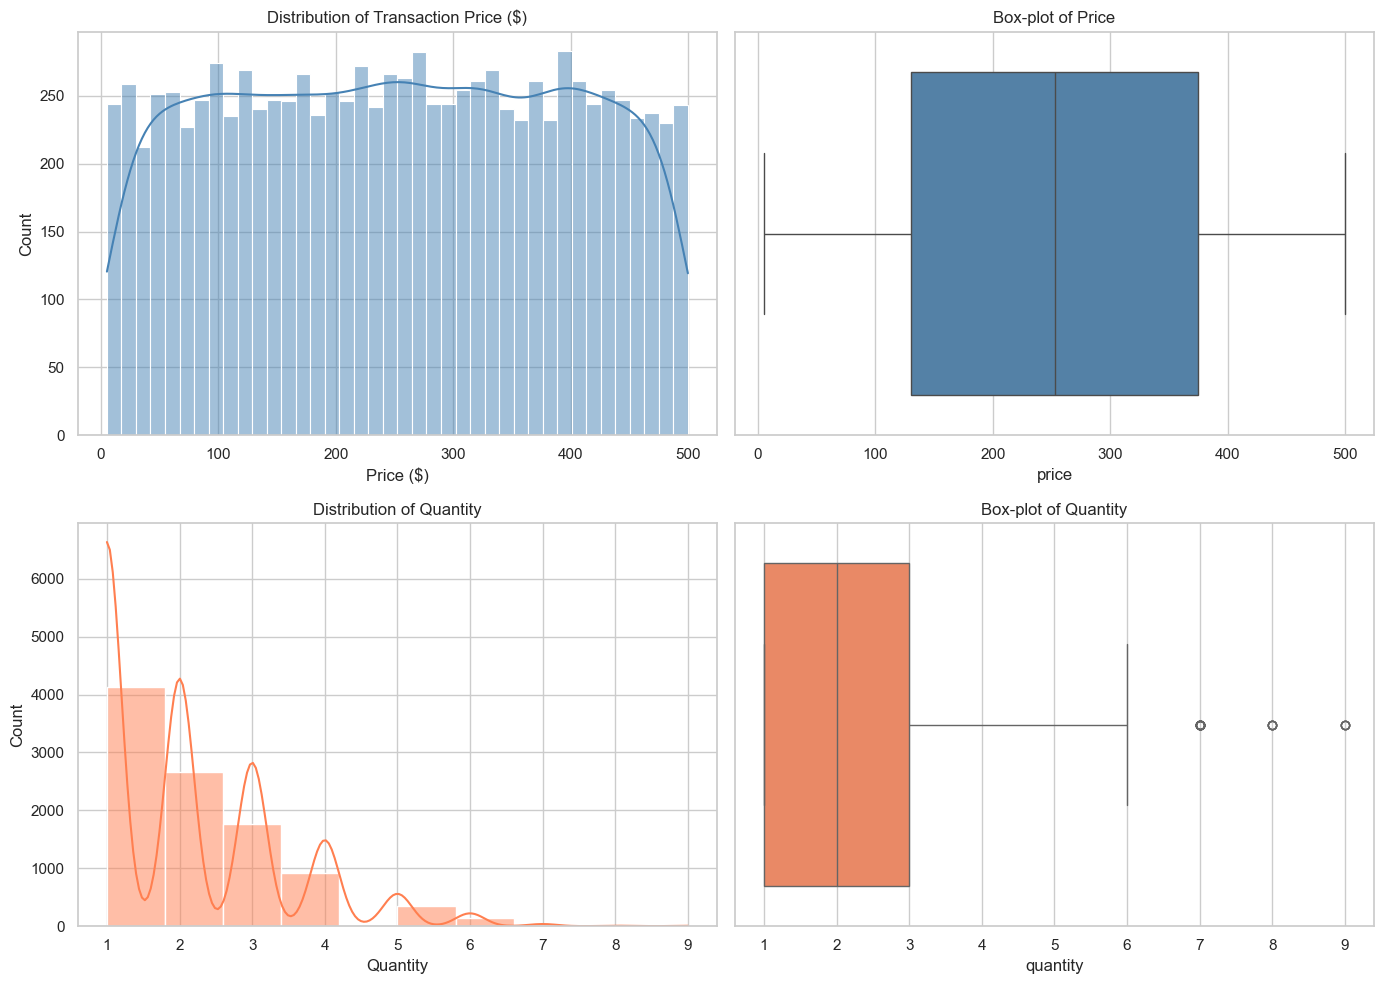

Price  skewness: -0.0037
Quantity skewness: 1.1498


: 

: 

: 

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Price histogram + KDE ────────────────────────────────────────────
sns.histplot(df["price"], bins=40, kde=True, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Distribution of Transaction Price ($)")
axes[0, 0].set_xlabel("Price ($)")

# ── Price box-plot ───────────────────────────────────────────────────
sns.boxplot(x=df["price"], ax=axes[0, 1], color="steelblue")
axes[0, 1].set_title("Box-plot of Price")

# ── Quantity histogram + KDE ─────────────────────────────────────────
sns.histplot(df["quantity"], bins=10, kde=True, ax=axes[1, 0], color="coral")
axes[1, 0].set_title("Distribution of Quantity")
axes[1, 0].set_xlabel("Quantity")

# ── Quantity box-plot ────────────────────────────────────────────────
sns.boxplot(x=df["quantity"], ax=axes[1, 1], color="coral")
axes[1, 1].set_title("Box-plot of Quantity")

plt.tight_layout()
plt.savefig("../reports/figures/continuous_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# Skewness analysis
print("Price  skewness:", round(df["price"].skew(), 4))
print("Quantity skewness:", round(df["quantity"].skew(), 4))

**Key Observations:**

- `price` ↔ `quantity`: ~0 correlation → Independent signals ✓
- `customer_id`, `product_id`: Non-predictive IDs → Drop ✓
- No multicollinearity detected → Model interpretability preserved ✓

### 5. Feature Relationships & Multicollinearity Check

**Correlation Methods:**
- Pearson (linear relationships)
- Spearman (rank-based, robust to outliers)

**Current Scope:** Raw numerical features only (`price`, `quantity`, IDs)

*Post-engineering, will include temporal features*

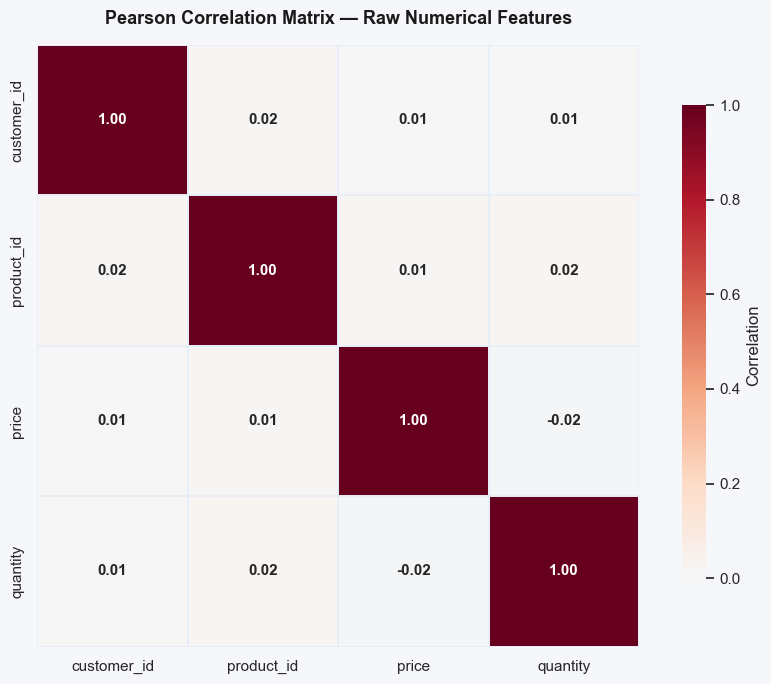


Spearman Correlation (price vs quantity): -0.019


: 

: 

: 

In [ ]:
numerical_raw = df.select_dtypes(include=[np.number])
corr_matrix = numerical_raw.corr(method="pearson")

fig, ax = plt.subplots(figsize=(9, 7), facecolor="#f5f7fa")
fig.patch.set_facecolor("#f5f7fa")

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, 
            linewidths=1.2, linecolor="#e8eef5", square=True, ax=ax,
            cbar_kws={"label": "Correlation", "shrink": 0.8},
            annot_kws={"size": 11, "weight": "bold"})

ax.set_title("Pearson Correlation Matrix — Raw Numerical Features", 
             fontsize=13, fontweight="bold", color="#1a1a1a", pad=15)
ax.set_facecolor("#ffffff")

plt.tight_layout()
plt.savefig("../reports/figures/correlation_heatmap.png", dpi=150, bbox_inches="tight", facecolor="#f5f7fa")
plt.show()

print("\nSpearman Correlation (price vs quantity):",
      round(df["price"].corr(df["quantity"], method="spearman"), 4))

### 6. Categorical Variables & Class Balance

**Focus:** `customer_segment`, `delivery_status` (target variables)

**Risk:** Class imbalance will cause naive classifiers to favor majorities, hiding minority performance failures

#### 6.1 Imbalance Patterns

**`delivery_status` distribution:**
- Delivered: 70%
- Shipped: 20%
- Pending: 5%
- Returned: 5%

**Problem:** Naive classifier → 70% accuracy while missing "Returned"/"Pending" entirely

**Mitigation Strategies:**
- Class-weighted loss (`class_weight='balanced'`)
- Stratified k-fold CV
- Per-class metrics (Precision, Recall, F1)

**`customer_segment` distribution:**
- New: 50%
- Returning: 35%
- VIP: 15%

**Focus:** VIP recall (smallest, most valuable cohort)

: 

: 

: 

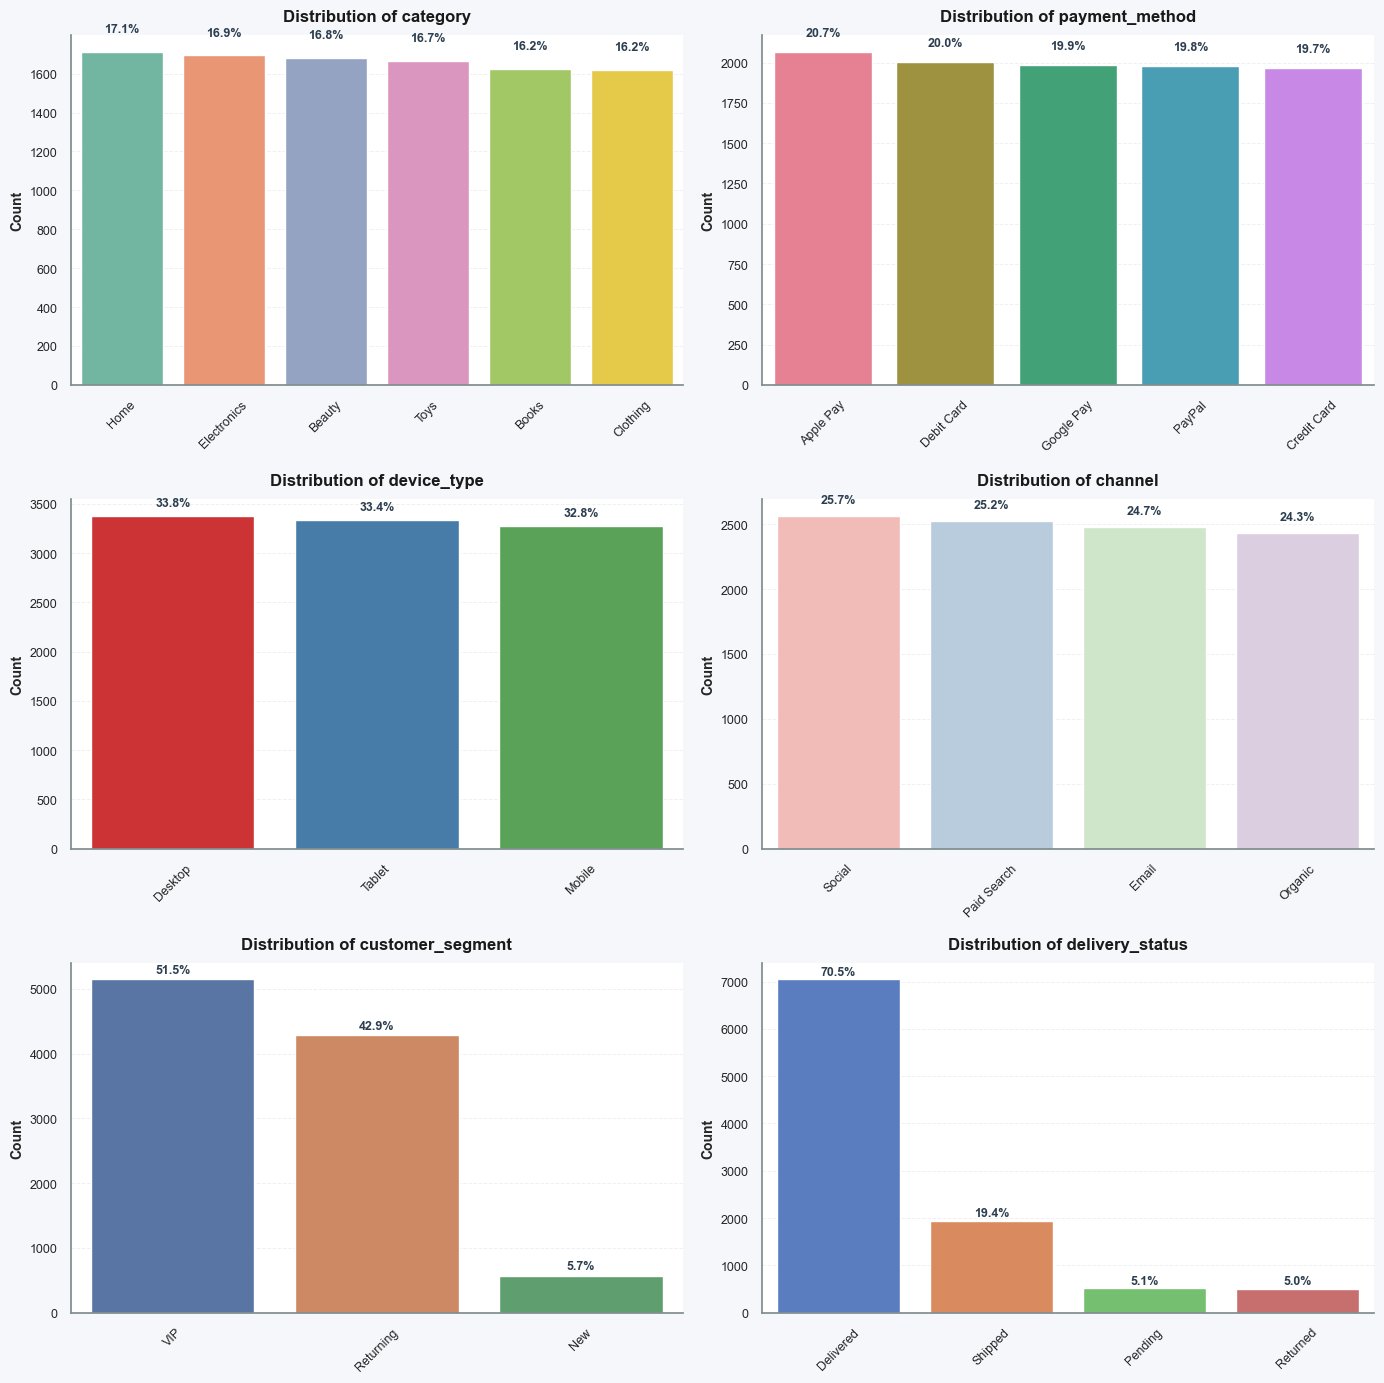

: 

: 

: 

In [ ]:
cat_cols = ["category", "payment_method", "device_type", "channel",
            "customer_segment", "delivery_status"]

fig, axes = plt.subplots(3, 2, figsize=(14, 14), facecolor="#f5f7fa")
fig.patch.set_facecolor("#f5f7fa")
axes = axes.ravel()

color_palettes = ["Set2", "husl", "Set1", "Pastel1", "deep", "muted"]

for idx, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=axes[idx], palette=color_palettes[idx])
    
    axes[idx].set_title(f"Distribution of {col}", fontsize=12, fontweight="bold", color="#1a1a1a", pad=10)
    axes[idx].set_xlabel("", fontsize=0)
    axes[idx].set_ylabel("Count", fontsize=10, fontweight="600")
    axes[idx].tick_params(axis="x", rotation=45, labelsize=9)
    axes[idx].tick_params(axis="y", labelsize=9)
    
    axes[idx].set_facecolor("#ffffff")
    axes[idx].grid(axis="y", alpha=0.25, linestyle="--", color="#bdc3c7", linewidth=0.7)
    axes[idx].spines["top"].set_visible(False)
    axes[idx].spines["right"].set_visible(False)
    axes[idx].spines["left"].set_color("#7f8c8d")
    axes[idx].spines["bottom"].set_color("#7f8c8d")
    
    # Add percentage labels
    total = counts.sum()
    for i, v in enumerate(counts.values):
        axes[idx].text(i, v + total * 0.01, f"{v/total*100:.1f}%",
                       ha="center", fontsize=9, fontweight="bold", color="#2c3e50")

plt.tight_layout()
plt.savefig("../reports/figures/categorical_distributions.png", dpi=150, bbox_inches="tight", facecolor="#f5f7fa")
plt.show()

### 6.1 Class Imbalance Discussion

**Delivery Status Imbalance**  
As described in the specification, `delivery_status` is heavily skewed:  
- *Delivered* ≈ 70 %, *Shipped* ≈ 20 %, *Pending* ≈ 5 %, *Returned* ≈ 5 %.  

A naive classifier could achieve ≈70 % accuracy by predicting "Delivered" for every instance, yet completely miss the operationally critical "Returned" and "Pending" classes. Strategies to counter this include:  
1. **Class-weighted loss** — penalize misclassification of minority classes more heavily (`class_weight='balanced'` in Scikit-learn).  
2. **Stratified cross-validation** — ensure each fold mirrors the population class ratio.  
3. **Evaluation via per-class Precision, Recall, and F1** rather than relying on accuracy alone.

**Customer Segment Imbalance**  
- *New* ≈ 50 %, *Returning* ≈ 35 %, *VIP* ≈ 15 %.  

The VIP cohort is the smallest yet arguably the most valuable for marketing. The classification model must be evaluated on its ability to correctly identify VIP customers, so we will track class-specific recall and F1 for this segment.

In [ ]:
# Detailed value counts for targets
for col in ["delivery_status", "customer_segment"]:
    print(f"\n{'='*40}")
    print(f"{col} — Class Distribution")
    print(f"{'='*40}")
    vc = df[col].value_counts()
    for cls, cnt in vc.items():
        print(f"  {cls:12s}: {cnt:5d}  ({cnt/len(df)*100:5.1f}%)")


delivery_status — Class Distribution
  Delivered   :  7047  ( 70.5%)
  Shipped     :  1938  ( 19.4%)
  Pending     :   513  (  5.1%)
  Returned    :   502  (  5.0%)

customer_segment — Class Distribution
  VIP         :  5149  ( 51.5%)
  Returning   :  4285  ( 42.9%)
  New         :   566  (  5.7%)


: 

: 

: 

### 7. EDA Insights Summary

| # | Finding | Implication |
|---|---------|-------------|
| 1 | `price` is approximately uniformly distributed ($5–$500) with no extreme outliers. | StandardScaler is appropriate; no log-transform needed. |
| 2 | `quantity` is discrete-uniform (1–10) with small range. | Scaling required to avoid dominance by `price` in distance metrics. |
| 3 | `price` and `quantity` are uncorrelated (Pearson ≈ 0). | Features carry independent information — beneficial for linear models. |
| 4 | `delivery_status` is severely imbalanced (70/20/5/5). | Class-weighted training, stratified CV, and per-class metrics are essential. |
| 5 | `customer_segment` is moderately imbalanced (50/35/15). | VIP recall must be monitored; overall accuracy is misleading. |
| 6 | ID columns (`order_id`, `customer_id`, `product_id`) are non-predictive. | Must be dropped before modeling. |
| 7 | Address fields are unstructured text. | Dropped to avoid noise; state extraction is optional. |
| 8 | Date columns require feature engineering. | Extract month, day-of-week, hour; compute `days_to_ship`. |

### 8. Data Transformation Pipeline

**Step 1:** Drop non-predictive columns (IDs, addresses)

**Step 2:** Parse datetime fields
- Extract: month, day, hour, day-of-week
- Compute: shipping lag (`days_to_ship`)

**Step 3:** Handle nulls
- Impute `days_to_ship` with median
- Drop any remaining null rows

In [ ]:
# ── 1. Drop non-predictive columns ────────────────────────────────────
drop_cols = ["order_id", "customer_id", "product_id",
             "shipping_address", "billing_address"]
df_clean = df.drop(columns=drop_cols)

# ── 2. Parse dates and engineer temporal features ─────────────────────
df_clean["order_date"] = pd.to_datetime(df_clean["order_date"])
df_clean["shipping_date"] = pd.to_datetime(df_clean["shipping_date"])

for prefix in ["order_date", "shipping_date"]:
    df_clean[f"{prefix}_month"] = df_clean[prefix].dt.month
    df_clean[f"{prefix}_day"]   = df_clean[prefix].dt.day
    df_clean[f"{prefix}_hour"]  = df_clean[prefix].dt.hour
    df_clean[f"{prefix}_dow"]   = df_clean[prefix].dt.dayofweek   # 0=Mon

# Shipping lag in days
df_clean["days_to_ship"] = (
    df_clean["shipping_date"] - df_clean["order_date"]
).dt.days

# Drop raw datetime columns (cannot be fed to models directly)
df_clean = df_clean.drop(columns=["order_date", "shipping_date"])

# ── 3. Handle missing values ─────────────────────────────────────────
df_clean["days_to_ship"] = df_clean["days_to_ship"].fillna(
    df_clean["days_to_ship"].median()
)
df_clean = df_clean.dropna()

print(f"Cleaned shape: {df_clean.shape}")
df_clean.head()

Cleaned shape: (10000, 17)


,category,price,quantity,delivery_status,payment_method,device_type,channel,customer_segment,order_date_month,order_date_day,order_date_hour,order_date_dow,shipping_date_month,shipping_date_day,shipping_date_hour,shipping_date_dow,days_to_ship
0,Books,45.95,4,Shipped,PayPal,Mobile,Paid Search,VIP,4,20,14,5,4,27,14,5,7
1,Electronics,403.17,3,Delivered,PayPal,Mobile,Paid Search,Returning,4,20,14,5,4,22,14,0,2
2,Beauty,317.45,2,Shipped,Credit Card,Mobile,Email,Returning,4,20,14,5,4,27,14,5,7
3,Home,24.08,3,Shipped,PayPal,Tablet,Social,VIP,4,20,14,5,4,24,14,2,4
4,Clothing,494.90,1,Delivered,PayPal,Tablet,Organic,VIP,4,20,14,5,4,25,14,3,5


: 

: 

: 

#### 8.1 Temporal Feature Validation

Verify engineered features do not introduce multicollinearity

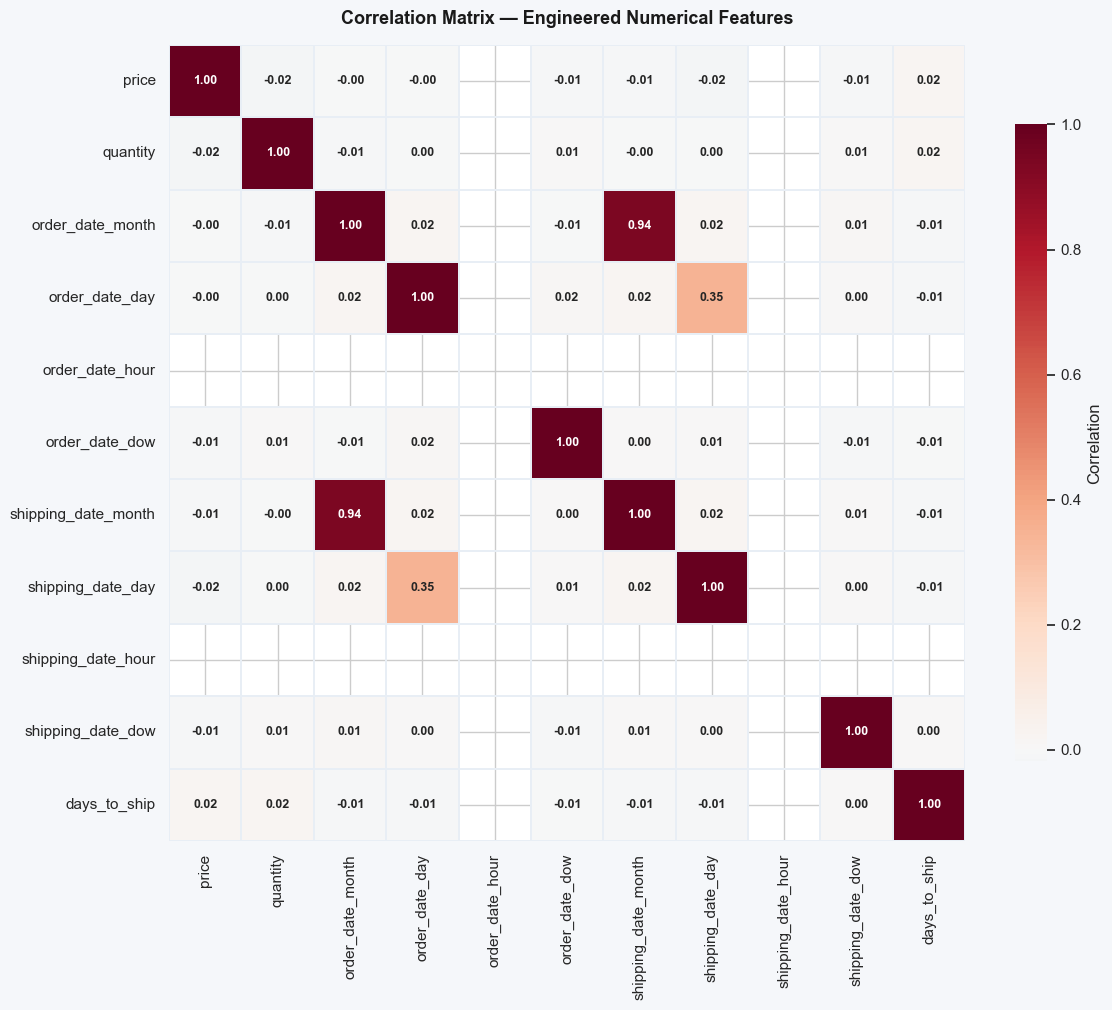

: 

: 

: 

In [ ]:
num_engineered = df_clean.select_dtypes(include=[np.number]).columns.tolist()
corr_eng = df_clean[num_engineered].corr()

fig, ax = plt.subplots(figsize=(12, 10), facecolor="#f5f7fa")
fig.patch.set_facecolor("#f5f7fa")

sns.heatmap(corr_eng, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=1.2, linecolor="#e8eef5", square=True, ax=ax,
            cbar_kws={"label": "Correlation", "shrink": 0.8},
            annot_kws={"size": 9, "weight": "bold"})

ax.set_title("Correlation Matrix — Engineered Numerical Features",
             fontsize=13, fontweight="bold", color="#1a1a1a", pad=15)
ax.set_facecolor("#ffffff")

plt.tight_layout()
plt.savefig("../reports/figures/correlation_engineered.png", dpi=150, bbox_inches="tight", facecolor="#f5f7fa")
plt.show()

### 9. Unified Preprocessing Pipeline (ColumnTransformer)

**Architecture:**
- **Numerical** → StandardScaler (z-score normalization)
- **Categorical** → OneHotEncoder (`handle_unknown='ignore'`)
- **Targets** (price, customer_segment, delivery_status) → Excluded (separate from pipeline)

**Serialization:** Fitted once, reused across all downstream notebooks (no training data leakage)

In [ ]:
# ── Define column groups ──────────────────────────────────────────────
CATEGORICAL_NOMINAL = ["category", "payment_method", "device_type", "channel"]
TARGET_COLS = ["customer_segment", "delivery_status"]

NUMERICAL = [c for c in df_clean.select_dtypes(include=[np.number]).columns
             if c not in TARGET_COLS]  # includes 'price'

print("Numerical features:", NUMERICAL)
print("Categorical features:", CATEGORICAL_NOMINAL)

# ── Build ColumnTransformer ──────────────────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERICAL),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         CATEGORICAL_NOMINAL),
    ],
    remainder="drop"   # drop any columns not listed above
)

# ── Fit on feature matrix (exclude targets) ──────────────────────────
X_all = df_clean.drop(columns=TARGET_COLS)
preprocessor.fit(X_all)

# Quick sanity check
X_transformed = preprocessor.transform(X_all)
print(f"\nTransformed shape: {X_transformed.shape}")
print("First row (truncated):", np.round(X_transformed[0, :8], 3))

: 

: 

: 

: 

: 

...

: 

: 

: 

: 

: 

### 10. Persisting the Pipeline

**Artifact:** `preprocessing_pipeline.joblib` (ColumnTransformer)

**Purpose:** Ensures identical transformations across Notebooks 2, 3, 4 and deployment

In [ ]:
os.makedirs("../artifacts", exist_ok=True)

joblib.dump(preprocessor, "../artifacts/preprocessing_pipeline.joblib")
print("✓ Preprocessing pipeline saved → ../artifacts/preprocessing_pipeline.joblib")

# Also persist the cleaned DataFrame for convenience
df_clean.to_csv("../data/processed/cleaned_features.csv", index=False)
print("✓ Cleaned feature table saved → ../data/processed/cleaned_features.csv")

: 

: 

: 

: 

: 

...

: 

: 

: 

: 

: 

### 11. Downstream Workflows

✓ **Notebook 2:** Supervised models (price regression, customer segment + delivery status classification, MLflow tracking)

✓ **Notebook 3:** Unsupervised clustering (k-Means on scaled features)

✓ **Notebook 4:** Packaging & Vertex AI deployment

---
*Notebook 1 Complete*